Acessos suspeitos detectados:
     cliente_id  hora  qtd_acessos  cliente  bot alerta_fraude
0        221958    18            2        0    0        ALERTA
3        465838     3            8        0    0        ALERTA
13       275203    17            1        1    1        ALERTA
32       358795    22            6        0    0        ALERTA
45       184654    14            2        0    1        ALERTA
61       339629     0            3        0    0        ALERTA
83       864469     0            1        0    1        ALERTA
113      336584     5            4        0    0        ALERTA
130      686146    18            3        0    0        ALERTA
134      234633    13            4        0    1        ALERTA


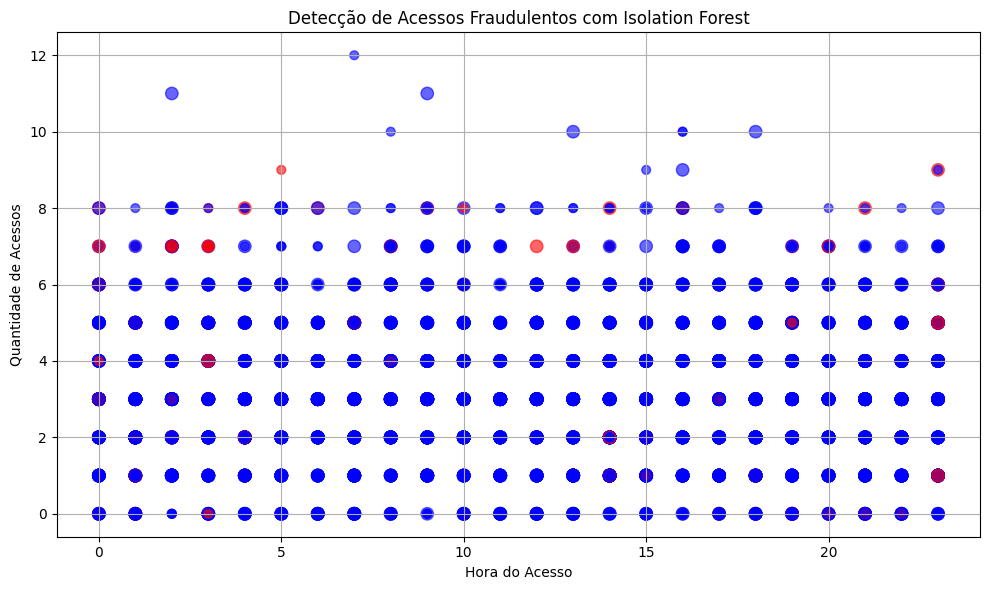

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Gerar dados simulados com milhares de clientes e países
def gerar_dados_bancarios(n=5000):
    np.random.seed(42)

    # Lista de países (ISO 3166 + alguns adicionais)
    paises = [
        'Brasil', 'Estados Unidos', 'Canadá', 'Alemanha', 'França', 'Reino Unido', 'China', 'Japão', 'Índia',
        'Rússia', 'Argentina', 'México', 'Austrália', 'África do Sul', 'Itália', 'Espanha', 'Coreia do Sul',
        'Suécia', 'Noruega', 'Dinamarca', 'Portugal', 'Chile', 'Colômbia', 'Peru', 'Venezuela', 'Egito', 'Turquia',
        'Indonésia', 'Paquistão', 'Irã', 'Arábia Saudita', 'Ucrânia', 'Polônia', 'Grécia', 'Suíça', 'Holanda',
        'Bélgica', 'Áustria', 'Finlândia', 'Nova Zelândia'
    ]

    # Cidades e regiões brasileiras
    cidades_br = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Brasília', 'Salvador', 'Curitiba', 'Fortaleza', 'Manaus', 'Recife', 'Porto Alegre']
    regioes_br = ['Sudeste', 'Sul', 'Centro-Oeste', 'Nordeste', 'Norte']

    # Tipos de dispositivos
    dispositivos = ['celular', 'computador', 'tablet', 'smartwatch']

    dados = pd.DataFrame({
        'cliente_id': np.random.randint(100000, 999999, n),
        'hora': np.random.randint(0, 24, n),
        'qtd_acessos': np.random.poisson(3, n),
        'pais': np.random.choice(paises, n),
        'cidade': np.random.choice(cidades_br, n),
        'regiao': np.random.choice(regioes_br, n),
        'dispositivo': np.random.choice(dispositivos, n),
        'cliente': np.random.choice([0, 1], n),  # 0 = visitante, 1 = cliente
        'bot': np.random.choice([0, 1], n)       # 0 = humano, 1 = bot
    })

    # Codificar variáveis categóricas
    dados = pd.get_dummies(dados, columns=['pais', 'cidade', 'regiao', 'dispositivo'], drop_first=True)
    return dados

# 2. Detectar acessos fraudulentos
def detectar_fraudes(dados):
    modelo = IsolationForest(contamination=0.05, random_state=42)
    modelo.fit(dados.drop(columns=['cliente_id']))
    dados['anomaly'] = modelo.predict(dados.drop(columns=['cliente_id']))
    dados['alerta_fraude'] = dados['anomaly'].apply(lambda x: 'ALERTA' if x == -1 else 'Normal')
    return dados

# 3. Executar pipeline
dados_simulados = gerar_dados_bancarios()
resultado = detectar_fraudes(dados_simulados)

# 4. Mostrar acessos suspeitos
fraudes = resultado[resultado['alerta_fraude'] == 'ALERTA']
print("Acessos suspeitos detectados:")
print(fraudes[['cliente_id', 'hora', 'qtd_acessos', 'cliente', 'bot', 'alerta_fraude']].head(10))

# 5. Gráfico de acessos
plt.figure(figsize=(10, 6))
cores = resultado['alerta_fraude'].map({'Normal': 'blue', 'ALERTA': 'red'})
tamanhos = resultado['bot'].map({0: 40, 1: 80})
plt.scatter(resultado['hora'], resultado['qtd_acessos'], c=cores, s=tamanhos, alpha=0.6)

plt.xlabel('Hora do Acesso')
plt.ylabel('Quantidade de Acessos')
plt.title('Detecção de Acessos Fraudulentos com Isolation Forest')
plt.grid(True)
plt.tight_layout()

# Salvar gráfico como evidência
plt.savefig("../docs/acessos-fraudulentos.png")
plt.show()
